# Dataverse MCP API Discovery: Tool-Use Regression Evaluation

This notebook empirically measures **tool-use degradation** when adding API discovery tools to a Dataverse MCP agent.

## Key Questions
1. **Does adding API tools cause regression on CRUD tasks?**
2. **Do agents prefer CRUD over process APIs when both are available?**
3. **Does "API-first" prompting tank CRUD scenarios?**
4. **Can selective API discovery improve process tasks without hurting CRUD?**

## Failure Modes Under Test
- **CRUD preference**: Agent updates fields directly instead of using process APIs
- **Wrong API guessing**: Agent calls incorrect APIs when none exists for the task
- **Parameter errors**: Agent finds correct API but fails to call it correctly
- **Over-exploration**: API-first strategy causes excessive tool calls on simple CRUD tasks

## 1) Setup

This notebook uses a **real LLM tool-calling loop**: the model chooses tools, we execute deterministic simulator functions, then feed tool outputs back until completion or step limit.

Authentication uses **Entra ID** via `az login` and `DefaultAzureCredential`.

In [1]:
# Install once if needed:
# %pip install openai pandas numpy tqdm matplotlib jsonschema scipy python-dotenv azure-identity

import os
import json
import uuid
import random
import hashlib
import copy
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple, Set
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from dotenv import load_dotenv
from azure.identity import DefaultAzureCredential

from openai import AzureOpenAI

In [2]:
# Load environment variables from .env
load_dotenv()

# Config
AZURE_OPENAI_ENDPOINT = os.environ.get("AZURE_OPENAI_ENDPOINT")
AZURE_OPENAI_API_VERSION = "2025-03-01-preview"
AZURE_OPENAI_DEPLOYMENT = os.environ.get("AZURE_OPENAI_DEPLOYMENT")

if not AZURE_OPENAI_ENDPOINT or not AZURE_OPENAI_DEPLOYMENT:
    raise EnvironmentError(
        "Missing required environment variables.\n"
        "Please set AZURE_OPENAI_ENDPOINT and AZURE_OPENAI_DEPLOYMENT in your .env file or environment.\n"
        "Example:\n"
        "  AZURE_OPENAI_ENDPOINT=https://your-resource.openai.azure.com/\n"
        "  AZURE_OPENAI_DEPLOYMENT=gpt-4o\n"
    )

MODEL = AZURE_OPENAI_DEPLOYMENT
TEMPERATURE = 0.0
MAX_AGENT_STEPS = 15

# Experiment config
TRIALS_PER_TASK = 1  # Increase for more statistical power
MAX_WORKERS = 4  # Parallel workers for experiments

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Cache for LLM calls
LLM_CACHE: Dict[str, Any] = {}

## 2) Dataverse World State

In-memory simulation of Dataverse tables and records needed for evaluation tasks.

In [26]:
# Tool Definitions - CRUD and API tools for the agent
# These simulate a Dataverse/CRM MCP server tool set

import random

# CRUD Tools (11 total - typical MCP CRUD operations)
CRUD_TOOLS = [
    "list_tables",
    "describe_table", 
    "fetch",
    "search",
    "read_query",
    "create_record",
    "update_record",
    "delete_record",
    "create_table",
    "update_table",
    "delete_table",
    "search",
]

# API Tools (3 total)
API_TOOLS = [
    "list_apis",
    "get_api_details",
    "invoke_api",
]

# Dummy Distractor Tools (3 total)
DUMMY_TOOLS = [
    "noop_tool_1",
    "noop_tool_2", 
    "noop_tool_3",
]

# Tool menu conditions
TOOL_CONDITIONS = {
    "crud_only": CRUD_TOOLS,  # 11 tools
    "crud_api": CRUD_TOOLS + API_TOOLS,  # 14 tools
    "crud_api_distractor": CRUD_TOOLS + API_TOOLS + DUMMY_TOOLS,  # 17 tools
}

# Tool Schemas for LLM
# NOTE: For OpenAI strict mode, all nested object types must have 
# "properties" and "additionalProperties": false
TOOL_SCHEMAS = {
    # CRUD Tools
    "list_tables": {
        "type": "object",
        "properties": {},
        "additionalProperties": False,
    },
    "describe_table": {
        "type": "object",
        "properties": {
            "table_name": {"type": "string", "description": "Logical name of the table"},
        },
        "required": ["table_name"],
        "additionalProperties": False,
    },
    "fetch": {
        "type": "object",
        "properties": {
            "record_id": {"type": "string", "description": "GUID of the record to fetch"},
        },
        "required": ["record_id"],
        "additionalProperties": False,
    },
    "search": {
        "type": "object",
        "properties": {
            "query_text": {"type": "string", "description": "Search query text"},
        },
        "required": ["query_text"],
        "additionalProperties": False,
    },
    "read_query": {
        "type": "object",
        "properties": {
            "query_text": {"type": "string", "description": "Query string (e.g., SELECT * FROM table)"},
        },
        "required": ["query_text"],
        "additionalProperties": False,
    },
    "create_record": {
        "type": "object",
        "properties": {
            "table_name": {"type": "string", "description": "Table to create record in"},
            "item_json": {
                "type": "object", 
                "description": "Record data as JSON object",
                "properties": {},
                "additionalProperties": True,  # Allow arbitrary fields for record data
            },
        },
        "required": ["table_name", "item_json"],
        "additionalProperties": False,
    },
    "update_record": {
        "type": "object",
        "properties": {
            "table_name": {"type": "string", "description": "Table containing the record"},
            "record_id": {"type": "string", "description": "GUID of the record to update"},
            "item_json": {
                "type": "object", 
                "description": "Fields to update as JSON object",
                "properties": {},
                "additionalProperties": True,  # Allow arbitrary fields for record data
            },
        },
        "required": ["table_name", "record_id", "item_json"],
        "additionalProperties": False,
    },
    "delete_record": {
        "type": "object",
        "properties": {
            "table_name": {"type": "string", "description": "Table containing the record"},
            "record_id": {"type": "string", "description": "GUID of the record to delete"},
            "has_user_approved": {"type": "boolean", "description": "Must be true to confirm deletion"},
        },
        "required": ["table_name", "record_id", "has_user_approved"],
        "additionalProperties": False,
    },
    "create_table": {
        "type": "object",
        "properties": {
            "table_name": {"type": "string", "description": "Logical name for the new table"},
            "display_name": {"type": "string", "description": "Display name for the table"},
            "columns_json": {"type": "array", "description": "Column definitions", "items": {"type": "object", "properties": {}, "additionalProperties": True}},
            "description": {"type": "string", "description": "Table description"},
        },
        "required": ["table_name", "display_name", "columns_json"],
        "additionalProperties": False,
    },
    "update_table": {
        "type": "object",
        "properties": {
            "table_name": {"type": "string", "description": "Table to update"},
            "columns_json": {"type": "array", "description": "New column definitions", "items": {"type": "object", "properties": {}, "additionalProperties": True}},
            "new_display_name": {"type": "string", "description": "New display name"},
            "description": {"type": "string", "description": "New description"},
        },
        "required": ["table_name", "columns_json"],
        "additionalProperties": False,
    },
    "delete_table": {
        "type": "object",
        "properties": {
            "table_name": {"type": "string", "description": "Table to delete"},
            "has_user_approved": {"type": "boolean", "description": "Must be true to confirm deletion"},
        },
        "required": ["table_name", "has_user_approved"],
        "additionalProperties": False,
    },
    # API Tools
    "list_apis": {
        "type": "object",
        "properties": {},
        "additionalProperties": False,
    },
    "get_api_details": {
        "type": "object",
        "properties": {
            "api_unique_name": {"type": "string", "description": "Unique name of the API"},
        },
        "required": ["api_unique_name"],
        "additionalProperties": False,
    },
    "invoke_api": {
        "type": "object",
        "properties": {
            "api_unique_name": {"type": "string", "description": "Unique name of the API to invoke"},
            "api_inputs_json": {
                "type": "object", 
                "description": "API input parameters as JSON object",
                "properties": {},
                "additionalProperties": True,  # Allow arbitrary API parameters
            },
        },
        "required": ["api_unique_name", "api_inputs_json"],
        "additionalProperties": False,
    },
    # Dummy Distractor Tools
    "noop_tool_1": {
        "type": "object",
        "properties": {
            "data": {"type": "string", "description": "Optional data parameter"},
        },
        "additionalProperties": False,
    },
    "noop_tool_2": {
        "type": "object",
        "properties": {
            "config": {
                "type": "object", 
                "description": "Optional configuration",
                "properties": {},
                "additionalProperties": True,
            },
        },
        "additionalProperties": False,
    },
    "noop_tool_3": {
        "type": "object",
        "properties": {
            "action": {"type": "string", "description": "Action to perform"},
        },
        "additionalProperties": False,
    },
}

TOOL_DESCRIPTIONS = {
    "list_tables": "List all available Dataverse tables",
    "describe_table": "Get schema details for a specific table",
    "fetch": "Fetch a record by its GUID from any table",
    "search": "Search for records matching query text across all tables",
    "read_query": "Execute a read query against Dataverse",
    "create_record": "Create a new record in a table",
    "update_record": "Update an existing record's fields",
    "delete_record": "Delete a record (requires user approval)",
    "create_table": "Create a new Dataverse table",
    "update_table": "Update a table's schema or metadata",
    "delete_table": "Delete a table (requires user approval)",
    "list_apis": "List all available process APIs",
    "get_api_details": "Get detailed information about an API including required inputs",
    "invoke_api": "Invoke a process API with specified inputs",
    "noop_tool_1": "Utility tool for data processing",
    "noop_tool_2": "Configuration management tool",
    "noop_tool_3": "Action execution helper",
}


def get_tool_definitions(tool_names: List[str], shuffle: bool = False, seed: int = 42) -> List[Dict[str, Any]]:
    """Generate tool definitions for the LLM.
    
    NOTE: We set strict=False because the nested object properties (item_json, api_inputs_json)
    need to accept arbitrary keys, which is incompatible with strict mode.
    """
    tools = tool_names.copy()
    if shuffle:
        rng = random.Random(seed)
        rng.shuffle(tools)
    
    defs = []
    for name in tools:
        schema = TOOL_SCHEMAS.get(name, {"type": "object", "properties": {}, "additionalProperties": False})
        defs.append({
            "type": "function",
            "name": name,
            "description": TOOL_DESCRIPTIONS.get(name, f"Tool: {name}"),
            "parameters": schema,
            "strict": False,  # Must be False for tools with additionalProperties: true in nested objects
        })
    return defs

## 3) API Catalog\n\nDefines the available process APIs with intentionally poor/vague descriptions to simulate real-world conditions.\nIncludes correct APIs and decoy APIs that can mislead the agent.

In [4]:
# API Catalog - includes correct APIs, decoy APIs, and poor descriptions

API_CATALOG = {
    # === CORRECT APIs for eval tasks ===
    "msdyn_HandOffAccount": {
        "display_name": "Hand Off Account",
        "description": "Transfer account ownership",  # Intentionally vague
        "inputs": {
            "accountid": {"type": "string", "required": True, "description": "Account GUID"},
            "newownerid": {"type": "string", "required": True, "description": "New owner user GUID"},
        },
        "is_correct": True,
    },
    "msdyn_QualifyLead": {
        "display_name": "Qualify Lead",
        "description": "",  # Empty description - real problem
        "inputs": {
            "leadid": {"type": "string", "required": True, "description": "Lead GUID"},
            "createaccount": {"type": "boolean", "required": False, "description": "Create account from lead"},
            "createcontact": {"type": "boolean", "required": False, "description": "Create contact from lead"},
            "createopportunity": {"type": "boolean", "required": False, "description": "Create opportunity from lead"},
        },
        "is_correct": True,
    },
    "msdyn_MergeContacts": {
        "display_name": "Merge Contacts",
        "description": "Merge two contact records",
        "inputs": {
            "mastercontactid": {"type": "string", "required": True, "description": "Master contact GUID to keep"},
            "subordinatecontactid": {"type": "string", "required": True, "description": "Contact GUID to merge and deactivate"},
            "performparentreparenting": {"type": "boolean", "required": False, "description": "Reparent child records"},
        },
        "is_correct": True,
    },
    "msdyn_OpportunitySummary": {
        "display_name": "Get Opportunity Summary",
        "description": "AI-generated opportunity summary",  # Vague
        "inputs": {
            "opportunityid": {"type": "string", "required": True, "description": "Opportunity GUID"},
        },
        "is_correct": True,
    },
    "msdyn_ExpandOperatingHoursForEntityCollection": {
        "display_name": "Expand Operating Hours",
        "description": "",  # Empty description
        "inputs": {
            "entitytype": {"type": "string", "required": True, "description": "Entity logical name"},
            "hourstoextend": {"type": "integer", "required": True, "description": "Hours to extend"},
        },
        "is_correct": True,
    },
    "msdyn_GetRelatedOpportunitiesForOpptyResearch": {
        "display_name": "Get Related Opportunities",
        "description": "Research related oppty",  # Poor abbreviation
        "inputs": {
            "opportunityid": {"type": "string", "required": True, "description": "Opportunity GUID"},
            "maxresults": {"type": "integer", "required": False, "description": "Max results to return"},
        },
        "is_correct": True,
    },
    "msdyn_markunmarkfavoritearticle": {
        "display_name": "Mark/Unmark Favorite Article",
        "description": "Toggle favorite status",  # Vague
        "inputs": {
            "articleid": {"type": "string", "required": True, "description": "Knowledge article GUID"},
            "markfavorite": {"type": "boolean", "required": True, "description": "True to mark, False to unmark"},
        },
        "is_correct": True,
    },
    
    # === DECOY APIs - plausible but wrong ===
    "msdyn_SalesAccountCatchup": {
        "display_name": "Sales Account Catchup",
        "description": "Sync account sales data",  # Could be confused with recalculate rollups
        "inputs": {
            "accountid": {"type": "string", "required": True, "description": "Account GUID"},
        },
        "is_decoy": True,
    },
    "msdyn_RefreshAccountMetrics": {
        "display_name": "Refresh Account Metrics",
        "description": "Update metrics",  # Vague - could be confused with health score
        "inputs": {
            "accountid": {"type": "string", "required": True, "description": "Account GUID"},
            "metrictype": {"type": "string", "required": False, "description": "Type of metric"},
        },
        "is_decoy": True,
    },
    "msdyn_AssignRecord": {
        "display_name": "Assign Record",
        "description": "Assign any record",  # Could be confused with HandOffAccount
        "inputs": {
            "entitytype": {"type": "string", "required": True, "description": "Entity type"},
            "recordid": {"type": "string", "required": True, "description": "Record GUID"},
            "assigneeid": {"type": "string", "required": True, "description": "Assignee GUID"},
        },
        "is_decoy": True,
    },
    "msdyn_UpdateLeadStatus": {
        "display_name": "Update Lead Status",
        "description": "",  # Empty - could be confused with QualifyLead
        "inputs": {
            "leadid": {"type": "string", "required": True, "description": "Lead GUID"},
            "statuscode": {"type": "integer", "required": True, "description": "New status code"},
        },
        "is_decoy": True,
    },
    "msdyn_ContactMergeHelper": {
        "display_name": "Contact Merge Helper",
        "description": "Help with contact operations",  # Vague
        "inputs": {
            "contactids": {"type": "array", "required": True, "description": "List of contact GUIDs"},
        },
        "is_decoy": True,
    },
    "msdyn_KnowledgeArticleAction": {
        "display_name": "Knowledge Article Action",
        "description": "Perform action on article",  # Too vague
        "inputs": {
            "articleid": {"type": "string", "required": True, "description": "Article GUID"},
            "actiontype": {"type": "string", "required": True, "description": "Action to perform"},
        },
        "is_decoy": True,
    },
}


def get_api_list() -> List[Dict[str, str]]:
    """Return list of APIs with basic info (name, display_name, description)."""
    return [
        {
            "api_unique_name": name,
            "display_name": info["display_name"],
            "description": info["description"],
        }
        for name, info in API_CATALOG.items()
    ]


def get_api_details(api_name: str) -> Optional[Dict[str, Any]]:
    """Return detailed API info including inputs schema."""
    if api_name not in API_CATALOG:
        return None
    info = API_CATALOG[api_name]
    return {
        "api_unique_name": api_name,
        "display_name": info["display_name"],
        "description": info["description"],
        "inputs": info["inputs"],
    }

## 4) CRUD Tool Implementations\n\nThe 11 CRUD tools that operate on Dataverse tables and records.

In [5]:
# CRUD Tool Implementations

def tool_list_tables(state: DataverseWorldState) -> Dict[str, Any]:
    """List all available tables."""
    return {
        "tables": [
            {"logical_name": name, "display_name": info["display_name"], "description": info["description"]}
            for name, info in state.tables.items()
        ]
    }


def tool_describe_table(state: DataverseWorldState, table_name: str) -> Dict[str, Any]:
    """Describe a table's schema."""
    if table_name not in state.tables:
        return {"error": f"Table '{table_name}' not found"}
    table = state.tables[table_name]
    return {
        "logical_name": table_name,
        "display_name": table["display_name"],
        "description": table["description"],
        "columns": table["columns"],
    }


def tool_fetch(state: DataverseWorldState, record_id: str) -> Dict[str, Any]:
    """Fetch a record by ID from any table."""
    for table_name, records in state.records.items():
        if record_id in records:
            return {"table": table_name, "record": records[record_id]}
    return {"error": f"Record '{record_id}' not found"}


def tool_search(state: DataverseWorldState, query_text: str) -> Dict[str, Any]:
    """Search for records matching query text (simple keyword matching)."""
    query_lower = query_text.lower()
    results = []
    for table_name, records in state.records.items():
        for record_id, record in records.items():
            # Simple keyword matching on string fields
            record_str = json.dumps(record).lower()
            if query_lower in record_str:
                results.append({
                    "table": table_name,
                    "record_id": record_id,
                    "preview": {k: v for k, v in record.items() if isinstance(v, (str, int, bool))},
                })
    return {"results": results[:20]}  # Limit results


def tool_read_query(state: DataverseWorldState, query_text: str) -> Dict[str, Any]:
    """Execute a read query (simplified - interprets as table filter)."""
    # Simple query parser: "SELECT * FROM table WHERE field = value"
    query_lower = query_text.lower()
    
    # Try to extract table name
    for table_name in state.tables:
        if table_name in query_lower:
            records = list(state.records.get(table_name, {}).values())
            return {"table": table_name, "records": records}
    
    return {"error": "Could not parse query. Use format: SELECT * FROM <table>"}


def tool_create_record(state: DataverseWorldState, table_name: str, item_json: Dict[str, Any]) -> Dict[str, Any]:
    """Create a new record in a table."""
    if table_name not in state.tables:
        return {"error": f"Table '{table_name}' not found"}
    
    # Generate new ID
    record_id = str(uuid.uuid4())
    
    # Find primary key column
    primary_col = None
    for col in state.tables[table_name]["columns"]:
        if col.get("primary"):
            primary_col = col["name"]
            break
    
    if primary_col:
        item_json[primary_col] = record_id
    
    state.records[table_name][record_id] = item_json
    state.crud_writes.append({"operation": "create", "table": table_name, "record_id": record_id})
    
    return {"record_id": record_id, "created": True}


def tool_update_record(state: DataverseWorldState, table_name: str, record_id: str, item_json: Dict[str, Any]) -> Dict[str, Any]:
    """Update an existing record."""
    if table_name not in state.tables:
        return {"error": f"Table '{table_name}' not found"}
    if record_id not in state.records.get(table_name, {}):
        return {"error": f"Record '{record_id}' not found in {table_name}"}
    
    # Track the update
    state.crud_writes.append({
        "operation": "update",
        "table": table_name,
        "record_id": record_id,
        "fields_updated": list(item_json.keys()),
    })
    
    # Apply update
    state.records[table_name][record_id].update(item_json)
    
    return {"record_id": record_id, "updated": True}


def tool_delete_record(state: DataverseWorldState, table_name: str, record_id: str, has_user_approved: bool) -> Dict[str, Any]:
    """Delete a record (requires user approval)."""
    if not has_user_approved:
        return {"error": "Delete operation requires has_user_approved=true"}
    if table_name not in state.tables:
        return {"error": f"Table '{table_name}' not found"}
    if record_id not in state.records.get(table_name, {}):
        return {"error": f"Record '{record_id}' not found in {table_name}"}
    
    del state.records[table_name][record_id]
    state.crud_writes.append({"operation": "delete", "table": table_name, "record_id": record_id})
    
    return {"record_id": record_id, "deleted": True}


def tool_create_table(state: DataverseWorldState, table_name: str, display_name: str, 
                      columns_json: List[Dict], description: Optional[str] = None) -> Dict[str, Any]:
    """Create a new table."""
    if table_name in state.tables:
        return {"error": f"Table '{table_name}' already exists"}
    
    state.tables[table_name] = {
        "display_name": display_name,
        "description": description or "",
        "columns": columns_json,
    }
    state.records[table_name] = {}
    
    return {"table_name": table_name, "created": True}


def tool_update_table(state: DataverseWorldState, table_name: str, columns_json: List[Dict],
                      new_display_name: Optional[str] = None, description: Optional[str] = None) -> Dict[str, Any]:
    """Update a table's schema."""
    if table_name not in state.tables:
        return {"error": f"Table '{table_name}' not found"}
    
    if new_display_name:
        state.tables[table_name]["display_name"] = new_display_name
    if description is not None:
        state.tables[table_name]["description"] = description
    if columns_json:
        state.tables[table_name]["columns"] = columns_json
    
    return {"table_name": table_name, "updated": True}


def tool_delete_table(state: DataverseWorldState, table_name: str, has_user_approved: bool) -> Dict[str, Any]:
    """Delete a table (requires user approval)."""
    if not has_user_approved:
        return {"error": "Delete operation requires has_user_approved=true"}
    if table_name not in state.tables:
        return {"error": f"Table '{table_name}' not found"}
    
    del state.tables[table_name]
    if table_name in state.records:
        del state.records[table_name]
    
    return {"table_name": table_name, "deleted": True}

## 5) API Tools Implementation\n\nThe 3 API discovery and invocation tools.

In [6]:
# API Tools Implementation

def tool_list_apis(state: DataverseWorldState) -> Dict[str, Any]:
    """List all available process APIs."""
    return {"apis": get_api_list()}


def tool_get_api_details(state: DataverseWorldState, api_unique_name: str) -> Dict[str, Any]:
    """Get detailed information about an API including input schema."""
    details = get_api_details(api_unique_name)
    if details is None:
        return {"error": f"API '{api_unique_name}' not found"}
    return details


def tool_invoke_api(state: DataverseWorldState, api_unique_name: str, api_inputs_json: Dict[str, Any]) -> Dict[str, Any]:
    """Invoke a process API with the given inputs."""
    if api_unique_name not in API_CATALOG:
        return {"error": f"API '{api_unique_name}' not found"}
    
    api_info = API_CATALOG[api_unique_name]
    
    # Track API call
    state.api_calls.append({
        "api_unique_name": api_unique_name,
        "inputs": api_inputs_json,
        "is_correct": api_info.get("is_correct", False),
        "is_decoy": api_info.get("is_decoy", False),
    })
    
    # Validate required inputs
    for param_name, param_info in api_info["inputs"].items():
        if param_info.get("required") and param_name not in api_inputs_json:
            return {"error": f"Missing required parameter: {param_name}"}
    
    # Execute API behavior based on API name
    return execute_api_logic(state, api_unique_name, api_inputs_json)


def execute_api_logic(state: DataverseWorldState, api_name: str, inputs: Dict[str, Any]) -> Dict[str, Any]:
    """Execute the actual API logic and update world state."""
    
    # === CORRECT APIs ===
    if api_name == "msdyn_HandOffAccount":
        account_id = inputs.get("accountid")
        new_owner_id = inputs.get("newownerid")
        if account_id in state.records.get("account", {}):
            state.records["account"][account_id]["ownerid"] = new_owner_id
            return {"success": True, "message": f"Account handed off to {new_owner_id}"}
        return {"error": "Account not found"}
    
    if api_name == "msdyn_QualifyLead":
        lead_id = inputs.get("leadid")
        if lead_id in state.records.get("lead", {}):
            state.records["lead"][lead_id]["qualified"] = True
            state.records["lead"][lead_id]["statuscode"] = 3  # Qualified
            return {"success": True, "message": "Lead qualified", "qualified": True}
        return {"error": "Lead not found"}
    
    if api_name == "msdyn_MergeContacts":
        master_id = inputs.get("mastercontactid")
        subordinate_id = inputs.get("subordinatecontactid")
        if master_id in state.records.get("contact", {}) and subordinate_id in state.records.get("contact", {}):
            state.records["contact"][subordinate_id]["merged"] = True
            return {"success": True, "message": f"Contacts merged. Master: {master_id}"}
        return {"error": "One or both contacts not found"}
    
    if api_name == "msdyn_OpportunitySummary":
        opp_id = inputs.get("opportunityid")
        if opp_id in state.records.get("opportunity", {}):
            opp = state.records["opportunity"][opp_id]
            return {
                "success": True,
                "summary": f"AI Summary: {opp['name']} is a ${opp.get('estimatedvalue', 0):,} opportunity. {opp.get('description', '')}",
            }
        return {"error": "Opportunity not found"}
    
    if api_name == "msdyn_ExpandOperatingHoursForEntityCollection":
        entity_type = inputs.get("entitytype")
        hours = inputs.get("hourstoextend", 0)
        if entity_type == "queue":
            for oh_id, oh in state.records.get("msdyn_operatinghour", {}).items():
                oh["msdyn_endhour"] = oh.get("msdyn_endhour", 17) + hours
            return {"success": True, "message": f"Operating hours expanded by {hours} hours"}
        return {"error": f"Entity type {entity_type} not supported"}
    
    if api_name == "msdyn_GetRelatedOpportunitiesForOpptyResearch":
        opp_id = inputs.get("opportunityid")
        if opp_id in state.records.get("opportunity", {}):
            related = [
                {"opportunityid": oid, "name": o["name"]}
                for oid, o in state.records.get("opportunity", {}).items()
                if oid != opp_id
            ]
            return {"success": True, "related_opportunities": related}
        return {"error": "Opportunity not found"}
    
    if api_name == "msdyn_markunmarkfavoritearticle":
        article_id = inputs.get("articleid")
        mark_favorite = inputs.get("markfavorite", True)
        if article_id in state.records.get("msdyn_knowledgearticle", {}):
            state.records["msdyn_knowledgearticle"][article_id]["isfavorite"] = mark_favorite
            return {"success": True, "message": f"Article favorite status set to {mark_favorite}"}
        return {"error": "Knowledge article not found"}
    
    # === DECOY APIs ===
    if api_name == "msdyn_SalesAccountCatchup":
        state.corruption_flags.append(f"Called decoy API {api_name}")
        return {"success": True, "message": "Account catchup initiated (WARNING: wrong API)"}
    
    if api_name == "msdyn_RefreshAccountMetrics":
        state.corruption_flags.append(f"Called decoy API {api_name}")
        return {"success": True, "message": "Metrics refresh initiated"}
    
    if api_name == "msdyn_AssignRecord":
        state.corruption_flags.append(f"Called decoy API {api_name}")
        return {"success": True, "message": "Record assigned (WARNING: Use specific APIs)"}
    
    if api_name == "msdyn_UpdateLeadStatus":
        state.corruption_flags.append(f"Called decoy API {api_name}")
        return {"success": True, "message": "Status updated (WARNING: bypasses rules)"}
    
    if api_name == "msdyn_ContactMergeHelper":
        state.corruption_flags.append(f"Called decoy API {api_name}")
        return {"error": "Use msdyn_MergeContacts instead"}
    
    if api_name == "msdyn_KnowledgeArticleAction":
        state.corruption_flags.append(f"Called decoy API {api_name}")
        return {"error": "Invalid action type"}
    
    return {"error": f"API {api_name} not implemented"}

## 6) Tool Menu Conditions\n\nThree tool menu configurations to measure degradation:\n- **Condition 1 (CRUD-only)**: 11 CRUD tools\n- **Condition 2 (CRUD+API)**: 14 tools (11 CRUD + 3 API)\n- **Condition 3 (CRUD+API+Distractor)**: 17 tools (14 + 3 dummy distractors)

In [7]:
# Tool Menu Conditions

# CRUD Tools (11 total)
CRUD_TOOLS = [
    "create_record",
    "list_tables",
    "describe_table",
    "read_query",
    "create_table",
    "update_table",
    "delete_table",
    "update_record",
    "delete_record",
    "fetch",
    "search",
]

# API Tools (3 total)
API_TOOLS = [
    "list_apis",
    "get_api_details",
    "invoke_api",
]

# Dummy Distractor Tools (3 total)
DUMMY_TOOLS = [
    "noop_tool_1",
    "noop_tool_2", 
    "noop_tool_3",
]

# Tool menu conditions
TOOL_CONDITIONS = {
    "crud_only": CRUD_TOOLS,  # 11 tools
    "crud_api": CRUD_TOOLS + API_TOOLS,  # 14 tools
    "crud_api_distractor": CRUD_TOOLS + API_TOOLS + DUMMY_TOOLS,  # 17 tools
}

# Tool Schemas for LLM
TOOL_SCHEMAS = {
    # CRUD Tools
    "list_tables": {
        "type": "object",
        "properties": {},
        "additionalProperties": False,
    },
    "describe_table": {
        "type": "object",
        "properties": {
            "table_name": {"type": "string", "description": "Logical name of the table"},
        },
        "required": ["table_name"],
        "additionalProperties": False,
    },
    "fetch": {
        "type": "object",
        "properties": {
            "record_id": {"type": "string", "description": "GUID of the record to fetch"},
        },
        "required": ["record_id"],
        "additionalProperties": False,
    },
    "search": {
        "type": "object",
        "properties": {
            "query_text": {"type": "string", "description": "Search query text"},
        },
        "required": ["query_text"],
        "additionalProperties": False,
    },
    "read_query": {
        "type": "object",
        "properties": {
            "query_text": {"type": "string", "description": "Query string (e.g., SELECT * FROM table)"},
        },
        "required": ["query_text"],
        "additionalProperties": False,
    },
    "create_record": {
        "type": "object",
        "properties": {
            "table_name": {"type": "string", "description": "Table to create record in"},
            "item_json": {"type": "object", "description": "Record data as JSON object"},
        },
        "required": ["table_name", "item_json"],
        "additionalProperties": False,
    },
    "update_record": {
        "type": "object",
        "properties": {
            "table_name": {"type": "string", "description": "Table containing the record"},
            "record_id": {"type": "string", "description": "GUID of the record to update"},
            "item_json": {"type": "object", "description": "Fields to update as JSON object"},
        },
        "required": ["table_name", "record_id", "item_json"],
        "additionalProperties": False,
    },
    "delete_record": {
        "type": "object",
        "properties": {
            "table_name": {"type": "string", "description": "Table containing the record"},
            "record_id": {"type": "string", "description": "GUID of the record to delete"},
            "has_user_approved": {"type": "boolean", "description": "Must be true to confirm deletion"},
        },
        "required": ["table_name", "record_id", "has_user_approved"],
        "additionalProperties": False,
    },
    "create_table": {
        "type": "object",
        "properties": {
            "table_name": {"type": "string", "description": "Logical name for the new table"},
            "display_name": {"type": "string", "description": "Display name for the table"},
            "columns_json": {"type": "array", "description": "Column definitions"},
            "description": {"type": "string", "description": "Table description"},
        },
        "required": ["table_name", "display_name", "columns_json"],
        "additionalProperties": False,
    },
    "update_table": {
        "type": "object",
        "properties": {
            "table_name": {"type": "string", "description": "Table to update"},
            "columns_json": {"type": "array", "description": "New column definitions"},
            "new_display_name": {"type": "string", "description": "New display name"},
            "description": {"type": "string", "description": "New description"},
        },
        "required": ["table_name", "columns_json"],
        "additionalProperties": False,
    },
    "delete_table": {
        "type": "object",
        "properties": {
            "table_name": {"type": "string", "description": "Table to delete"},
            "has_user_approved": {"type": "boolean", "description": "Must be true to confirm deletion"},
        },
        "required": ["table_name", "has_user_approved"],
        "additionalProperties": False,
    },
    # API Tools
    "list_apis": {
        "type": "object",
        "properties": {},
        "additionalProperties": False,
    },
    "get_api_details": {
        "type": "object",
        "properties": {
            "api_unique_name": {"type": "string", "description": "Unique name of the API"},
        },
        "required": ["api_unique_name"],
        "additionalProperties": False,
    },
    "invoke_api": {
        "type": "object",
        "properties": {
            "api_unique_name": {"type": "string", "description": "Unique name of the API to invoke"},
            "api_inputs_json": {"type": "object", "description": "API input parameters as JSON object"},
        },
        "required": ["api_unique_name", "api_inputs_json"],
        "additionalProperties": False,
    },
    # Dummy Distractor Tools
    "noop_tool_1": {
        "type": "object",
        "properties": {
            "data": {"type": "string", "description": "Optional data parameter"},
        },
        "additionalProperties": False,
    },
    "noop_tool_2": {
        "type": "object",
        "properties": {
            "config": {"type": "object", "description": "Optional configuration"},
        },
        "additionalProperties": False,
    },
    "noop_tool_3": {
        "type": "object",
        "properties": {
            "action": {"type": "string", "description": "Action to perform"},
        },
        "additionalProperties": False,
    },
}

TOOL_DESCRIPTIONS = {
    "list_tables": "List all available Dataverse tables",
    "describe_table": "Get schema details for a specific table",
    "fetch": "Fetch a record by its GUID from any table",
    "search": "Search for records matching query text across all tables",
    "read_query": "Execute a read query against Dataverse",
    "create_record": "Create a new record in a table",
    "update_record": "Update an existing record's fields",
    "delete_record": "Delete a record (requires user approval)",
    "create_table": "Create a new Dataverse table",
    "update_table": "Update a table's schema or metadata",
    "delete_table": "Delete a table (requires user approval)",
    "list_apis": "List all available process APIs",
    "get_api_details": "Get detailed information about an API including required inputs",
    "invoke_api": "Invoke a process API with specified inputs",
    "noop_tool_1": "Utility tool for data processing",
    "noop_tool_2": "Configuration management tool",
    "noop_tool_3": "Action execution helper",
}


def get_tool_definitions(tool_names: List[str], shuffle: bool = False, seed: int = 42) -> List[Dict[str, Any]]:
    """Generate tool definitions for the LLM."""
    tools = tool_names.copy()
    if shuffle:
        rng = random.Random(seed)
        rng.shuffle(tools)
    
    defs = []
    for name in tools:
        schema = TOOL_SCHEMAS.get(name, {"type": "object", "properties": {}, "additionalProperties": False})
        defs.append({
            "type": "function",
            "name": name,
            "description": TOOL_DESCRIPTIONS.get(name, f"Tool: {name}"),
            "parameters": schema,
            "strict": True,
        })
    return defs

## 7) Eval Tasks\n\nDefines the 8 business process tasks and 6 control CRUD tasks for evaluation.

In [8]:
# Eval Tasks Definition

@dataclass
class EvalTask:
    """Defines an evaluation task with expected behavior."""
    task_id: str
    prompt: str
    task_type: str  # "business_process" or "control"
    expected_api: Optional[str]  # Expected API name (None if no API should be called)
    disallowed_apis: List[str]  # APIs that should NOT be called
    disallowed_crud_writes: List[Dict[str, Any]]  # CRUD writes that indicate policy failure
    state_assertions: List[Dict[str, Any]]  # Assertions on final state
    description: str  # Human description of expected behavior


# === BUSINESS PROCESS TASKS (8 total) ===
BUSINESS_PROCESS_TASKS = [
    EvalTask(
        task_id="bp_001_handoff_account",
        prompt="Hand off account Fourth Coffee (Sample) to Dan Smith",
        task_type="business_process",
        expected_api="msdyn_HandOffAccount",
        disallowed_apis=["msdyn_AssignRecord", "msdyn_SalesAccountCatchup"],
        disallowed_crud_writes=[{"table": "account", "fields": ["ownerid"]}],  # Should use API not direct update
        state_assertions=[
            {"table": "account", "record_id": GUID_FOURTH_COFFEE, "field": "ownerid", "expected": GUID_DAN_SMITH}
        ],
        description="Should use msdyn_HandOffAccount API, not CRUD update of owner field",
    ),
    EvalTask(
        task_id="bp_002_qualify_lead",
        prompt="Qualify the web inquiry Counts Vong (sample)",
        task_type="business_process",
        expected_api="msdyn_QualifyLead",
        disallowed_apis=["msdyn_UpdateLeadStatus"],
        disallowed_crud_writes=[{"table": "lead", "fields": ["statuscode", "qualified"]}],
        state_assertions=[
            {"table": "lead", "record_id": GUID_COUNTS_VONG, "field": "qualified", "expected": True}
        ],
        description="Should use msdyn_QualifyLead API, not CRUD update of status field",
    ),
    EvalTask(
        task_id="bp_003_merge_contacts",
        prompt="Merge the contacts Jim Glynn (sample) and Maria Campbell (sample) keeping Jim as the master",
        task_type="business_process",
        expected_api="msdyn_MergeContacts",
        disallowed_apis=["msdyn_ContactMergeHelper"],
        disallowed_crud_writes=[{"table": "contact", "fields": ["merged"]}],
        state_assertions=[
            {"table": "contact", "record_id": GUID_MARIA_CAMPBELL, "field": "merged", "expected": True}
        ],
        description="Should use msdyn_MergeContacts with correct master/subordinate parameters",
    ),
    EvalTask(
        task_id="bp_004_recalc_rollups",
        prompt="Recalculate rollups for account Fourth Coffee (Sample) and refresh its health score",
        task_type="business_process",
        expected_api=None,  # NO API exists for this
        disallowed_apis=["msdyn_SalesAccountCatchup", "msdyn_RefreshAccountMetrics"],  # Decoy APIs
        disallowed_crud_writes=[{"table": "account", "fields": ["healthscore"]}],
        state_assertions=[],  # No state change expected - should recognize no API exists
        description="Should NOT call any API - no supported API exists. Agent should recognize this.",
    ),
    EvalTask(
        task_id="bp_005_opportunity_summary",
        prompt=f"Give me a summary of opportunity {GUID_OPPORTUNITY_1}",
        task_type="business_process",
        expected_api="msdyn_OpportunitySummary",
        disallowed_apis=[],
        disallowed_crud_writes=[],
        state_assertions=[],  # Read-only operation
        description="Should use msdyn_OpportunitySummary API, not fetch record and make own summary",
    ),
    EvalTask(
        task_id="bp_006_expand_hours",
        prompt="Expand operating hours for all customer service queues by 2 hours",
        task_type="business_process",
        expected_api="msdyn_ExpandOperatingHoursForEntityCollection",
        disallowed_apis=[],
        disallowed_crud_writes=[{"table": "msdyn_operatinghour", "fields": ["msdyn_endhour"]}],
        state_assertions=[
            {"table": "msdyn_operatinghour", "record_id": "oh-001", "field": "msdyn_endhour", "expected": 19},
            {"table": "msdyn_operatinghour", "record_id": "oh-002", "field": "msdyn_endhour", "expected": 19},
        ],
        description="Should use msdyn_ExpandOperatingHoursForEntityCollection, not search and update records",
    ),
    EvalTask(
        task_id="bp_007_related_opportunities",
        prompt="Get related opportunities for opportunity '10 orders of Product SKU JJ202 (sample)'",
        task_type="business_process",
        expected_api="msdyn_GetRelatedOpportunitiesForOpptyResearch",
        disallowed_apis=[],
        disallowed_crud_writes=[],
        state_assertions=[],  # Read-only
        description="Should use msdyn_GetRelatedOpportunitiesForOpptyResearch, not search tables",
    ),
    EvalTask(
        task_id="bp_008_favorite_article",
        prompt="Mark the knowledge article 'Booking Travel' as favorite",
        task_type="business_process",
        expected_api="msdyn_markunmarkfavoritearticle",
        disallowed_apis=["msdyn_KnowledgeArticleAction"],
        disallowed_crud_writes=[{"table": "msdyn_knowledgearticle", "fields": ["isfavorite"]}],
        state_assertions=[
            {"table": "msdyn_knowledgearticle", "record_id": GUID_KNOWLEDGE_ARTICLE, "field": "isfavorite", "expected": True}
        ],
        description="Should use msdyn_markunmarkfavoritearticle API",
    ),
]

# === CONTROL TASKS (6 total) - Pure CRUD, should NOT require APIs ===
CONTROL_TASKS = [
    EvalTask(
        task_id="ctrl_001_update_phone",
        prompt="Update the phone number for Maria Campbell (sample) to 555-0101",
        task_type="control",
        expected_api=None,
        disallowed_apis=[],  # Any API call is wrong for this task
        disallowed_crud_writes=[],  # CRUD write is expected
        state_assertions=[
            {"table": "contact", "record_id": GUID_MARIA_CAMPBELL, "field": "telephone1", "expected": "555-0101"}
        ],
        description="Simple CRUD update - should NOT use any APIs",
    ),
    EvalTask(
        task_id="ctrl_002_list_tables",
        prompt="List all available tables in Dataverse",
        task_type="control",
        expected_api=None,
        disallowed_apis=[],
        disallowed_crud_writes=[],
        state_assertions=[],  # Read-only
        description="Should use list_tables, not API discovery",
    ),
    EvalTask(
        task_id="ctrl_003_describe_table",
        prompt="Describe the contact table schema",
        task_type="control",
        expected_api=None,
        disallowed_apis=[],
        disallowed_crud_writes=[],
        state_assertions=[],
        description="Should use describe_table for contact",
    ),
    EvalTask(
        task_id="ctrl_004_fetch_record",
        prompt=f"Fetch the record {GUID_FOURTH_COFFEE} and show me its fields",
        task_type="control",
        expected_api=None,
        disallowed_apis=[],
        disallowed_crud_writes=[],
        state_assertions=[],
        description="Should use fetch tool directly",
    ),
    EvalTask(
        task_id="ctrl_005_create_record",
        prompt="Create a new contact named 'Test User' with email test@example.com",
        task_type="control",
        expected_api=None,
        disallowed_apis=[],
        disallowed_crud_writes=[],  # Create is expected
        state_assertions=[],  # New record will have random ID
        description="Should use create_record for contact table",
    ),
    EvalTask(
        task_id="ctrl_006_delete_with_approval",
        prompt=f"Delete the contact Maria Campbell (sample) - I approve this deletion",
        task_type="control",
        expected_api=None,
        disallowed_apis=[],
        disallowed_crud_writes=[],
        state_assertions=[],  # Record should be deleted
        description="Should use delete_record with has_user_approved=true",
    ),
]

# Combine all tasks
ALL_TASKS = BUSINESS_PROCESS_TASKS + CONTROL_TASKS

print(f"Total tasks: {len(ALL_TASKS)}")
print(f"  Business process tasks: {len(BUSINESS_PROCESS_TASKS)}")
print(f"  Control tasks: {len(CONTROL_TASKS)}")

Total tasks: 14
  Business process tasks: 8
  Control tasks: 6


## 8) Prompting Strategies\n\nThree prompting strategies to test:\n- **S0 Baseline**: No special instruction\n- **S1 API-First**: Always call list_apis early\n- **S2 Selective Discovery**: Use APIs for business processes, CRUD for simple operations

In [9]:
# Prompting Strategies

STRATEGY_PROMPTS = {
    "S0_baseline": """You are a Dataverse assistant. Use the available tools to complete the user's request.
Call tools as needed to accomplish the task. Return a concise response when done.""",

    "S1_api_first": """You are a Dataverse assistant. Use the available tools to complete the user's request.

IMPORTANT: Before performing any operation, ALWAYS call list_apis() first to discover available process APIs.
If an API exists for the requested operation, use invoke_api() instead of direct CRUD operations.
Call get_api_details() to understand required parameters before invoking an API.

Return a concise response when done.""",

    "S2_selective_discovery": """You are a Dataverse assistant. Use the available tools to complete the user's request.

Follow this decision process:
1. Determine if the request is a BUSINESS PROCESS action or a simple DATA operation:
   - BUSINESS PROCESS actions include: handoff, qualify, merge, recalculate, expand hours, 
     mark as favorite, get summaries, get related records, or other process-oriented verbs
   - DATA operations include: list, describe, fetch, search, create, update, delete records/tables

2. For BUSINESS PROCESS actions:
   a) Call list_apis() to discover available process APIs
   b) Identify 3-8 candidate APIs by matching name/description to the request
   c) Call get_api_details() for the top candidates to understand required inputs
   d) Call invoke_api() with the correct API and parameters
   e) If no suitable API exists, inform the user rather than using workarounds

3. For DATA operations:
   - Use the appropriate CRUD tools directly (search, fetch, update_record, etc.)
   - Do NOT call list_apis() for simple data operations

Return a concise response when done.""",
}

STRATEGIES = list(STRATEGY_PROMPTS.keys())
print(f"Strategies: {STRATEGIES}")

Strategies: ['S0_baseline', 'S1_api_first', 'S2_selective_discovery']


## 9) Azure OpenAI Client & Tool Executor\n\nSets up authentication and implements the tool execution dispatcher.

In [10]:
# Azure OpenAI Client Setup

AZURE_SCOPE = "https://cognitiveservices.azure.com/.default"

# Get optional API key and tenant from environment
AZURE_OPENAI_API_KEY = os.environ.get("AZURE_OPENAI_API_KEY")
AZURE_TENANT_ID = os.environ.get("AZURE_TENANT_ID")

_cached_credential = None
_cached_client = None


def get_azure_client() -> AzureOpenAI:
    """Get or create Azure OpenAI client.
    
    Authentication priority:
    1. API Key (if AZURE_OPENAI_API_KEY is set)
    2. Entra ID with tenant (if AZURE_TENANT_ID is set)
    3. DefaultAzureCredential fallback
    """
    global _cached_credential, _cached_client
    if _cached_client is None:
        if AZURE_OPENAI_API_KEY:
            # Use API key authentication
            print("Using API Key authentication")
            _cached_client = AzureOpenAI(
                azure_endpoint=AZURE_OPENAI_ENDPOINT,
                api_version=AZURE_OPENAI_API_VERSION,
                api_key=AZURE_OPENAI_API_KEY,
            )
        else:
            # Use Entra ID authentication
            print("Using Entra ID authentication")
            if AZURE_TENANT_ID:
                # Use specified tenant to avoid tenant mismatch
                from azure.identity import AzureCliCredential, ChainedTokenCredential, ManagedIdentityCredential
                print(f"  with tenant: {AZURE_TENANT_ID}")
                _cached_credential = ChainedTokenCredential(
                    AzureCliCredential(tenant_id=AZURE_TENANT_ID),
                    ManagedIdentityCredential(),
                )
            else:
                _cached_credential = DefaultAzureCredential()
            
            token_provider = lambda: _cached_credential.get_token(AZURE_SCOPE).token
            _cached_client = AzureOpenAI(
                azure_endpoint=AZURE_OPENAI_ENDPOINT,
                api_version=AZURE_OPENAI_API_VERSION,
                azure_ad_token_provider=token_provider,
            )
    return _cached_client


# Tool Executor

def execute_tool(tool_name: str, args: Dict[str, Any], state: DataverseWorldState) -> Dict[str, Any]:
    """Execute a tool and return the result."""
    try:
        # CRUD Tools
        if tool_name == "list_tables":
            return tool_list_tables(state)
        if tool_name == "describe_table":
            return tool_describe_table(state, args.get("table_name", ""))
        if tool_name == "fetch":
            return tool_fetch(state, args.get("record_id", ""))
        if tool_name == "search":
            return tool_search(state, args.get("query_text", ""))
        if tool_name == "read_query":
            return tool_read_query(state, args.get("query_text", ""))
        if tool_name == "create_record":
            return tool_create_record(state, args.get("table_name", ""), args.get("item_json", {}))
        if tool_name == "update_record":
            return tool_update_record(
                state, 
                args.get("table_name", ""), 
                args.get("record_id", ""), 
                args.get("item_json", {})
            )
        if tool_name == "delete_record":
            return tool_delete_record(
                state,
                args.get("table_name", ""),
                args.get("record_id", ""),
                args.get("has_user_approved", False)
            )
        if tool_name == "create_table":
            return tool_create_table(
                state,
                args.get("table_name", ""),
                args.get("display_name", ""),
                args.get("columns_json", []),
                args.get("description")
            )
        if tool_name == "update_table":
            return tool_update_table(
                state,
                args.get("table_name", ""),
                args.get("columns_json", []),
                args.get("new_display_name"),
                args.get("description")
            )
        if tool_name == "delete_table":
            return tool_delete_table(
                state,
                args.get("table_name", ""),
                args.get("has_user_approved", False)
            )
        
        # API Tools
        if tool_name == "list_apis":
            return tool_list_apis(state)
        if tool_name == "get_api_details":
            return tool_get_api_details(state, args.get("api_unique_name", ""))
        if tool_name == "invoke_api":
            return tool_invoke_api(
                state,
                args.get("api_unique_name", ""),
                args.get("api_inputs_json", {})
            )
        
        # Dummy/Distractor Tools
        if tool_name in DUMMY_TOOLS:
            return {"status": "noop", "message": f"{tool_name} executed (no effect)"}
        
        return {"error": f"Unknown tool: {tool_name}"}
    
    except Exception as e:
        return {"error": f"Tool execution error: {str(e)}"}

In [27]:
# Clear LLM cache and client cache to retry with new authentication
# Reload environment variables in case they were updated
load_dotenv(override=True)

# Re-read optional auth env vars
AZURE_OPENAI_API_KEY = os.environ.get("AZURE_OPENAI_API_KEY")
AZURE_TENANT_ID = os.environ.get("AZURE_TENANT_ID")

LLM_CACHE.clear()
_cached_client = None
_cached_credential = None

print("Cleared LLM cache and client cache")
print(f"API Key configured: {bool(AZURE_OPENAI_API_KEY)}")
print(f"Tenant ID configured: {bool(AZURE_TENANT_ID)}")
print()

# Test the client connection
try:
    client = get_azure_client()
    # Make a simple test call
    test_response = client.responses.create(
        model=MODEL,
        input="Say hello",
        temperature=0,
    )
    print("✓ Client connection test: SUCCESS")
    print("\nYou can now re-run the experiment cells (cells 27-28 in the notebook)")
except Exception as e:
    import traceback
    error_str = str(e)
    print(f"✗ Client connection test: FAILED")
    print(f"\nFull Error:\n{error_str}")
    
    if "tenant" in error_str.lower():
        print("\n" + "="*60)
        print("AUTHENTICATION ERROR: Tenant Mismatch")
        print("="*60)
        print("""
The Azure OpenAI resource is in a different tenant than your current credentials.

To fix this, add one of the following to your .env file:

Option 1 - API Key (recommended):
  AZURE_OPENAI_API_KEY="your-api-key-here"
  
Option 2 - Tenant ID:
  AZURE_TENANT_ID="tenant-id-of-azure-openai-resource"
  
To find your Azure OpenAI API Key:
1. Go to Azure Portal -> Your Azure OpenAI Resource
2. Click "Keys and Endpoint" in the left menu
3. Copy Key 1 or Key 2

To find the Tenant ID:
1. Go to Azure Portal -> Your Azure OpenAI Resource  
2. Click "Overview"
3. The tenant is shown in the resource details
""")
    else:
        print("\n" + "="*60)
        print("CONNECTION ERROR")
        print("="*60)
        print("Please check your .env file configuration:")
        print(f"  AZURE_OPENAI_ENDPOINT: {AZURE_OPENAI_ENDPOINT}")
        print(f"  AZURE_OPENAI_DEPLOYMENT: {AZURE_OPENAI_DEPLOYMENT}")
    print("="*60)

Cleared LLM cache and client cache
API Key configured: False
Tenant ID configured: False

Using Entra ID authentication
✓ Client connection test: SUCCESS

You can now re-run the experiment cells (cells 27-28 in the notebook)


## 10) LLM Orchestration Loop\n\nThe core agent loop where the LLM decides tool calls, we execute them, and iterate until completion.

In [12]:
# LLM Orchestration Loop

@dataclass
class ToolCallRecord:
    """Record of a single tool call."""
    name: str
    args: Dict[str, Any]
    result: Dict[str, Any]


@dataclass
class EpisodeResult:
    """Result of running a single evaluation episode."""
    task_id: str
    strategy: str
    tool_condition: str
    seed: int
    shuffle_tools: bool
    
    # Execution data
    tool_calls: List[ToolCallRecord]
    final_state: DataverseWorldState
    completed: bool
    hit_max_steps: bool
    error: Optional[str]
    
    # Transcript for debugging
    transcript: List[Dict[str, Any]]


def get_cache_key(task_id: str, strategy: str, tool_condition: str, seed: int) -> str:
    """Generate cache key for LLM calls."""
    key_str = f"{task_id}:{strategy}:{tool_condition}:{seed}:{MODEL}"
    return hashlib.md5(key_str.encode()).hexdigest()


def run_episode(
    task: EvalTask,
    strategy: str,
    tool_condition: str,
    seed: int = 42,
    shuffle_tools: bool = False,
    use_cache: bool = True,
) -> EpisodeResult:
    """Run a single evaluation episode."""
    
    # Check cache
    cache_key = get_cache_key(task.task_id, strategy, tool_condition, seed)
    if use_cache and cache_key in LLM_CACHE:
        return LLM_CACHE[cache_key]
    
    # Initialize state
    state = create_initial_world_state()
    tool_names = TOOL_CONDITIONS[tool_condition]
    tool_defs = get_tool_definitions(tool_names, shuffle=shuffle_tools, seed=seed)
    system_prompt = STRATEGY_PROMPTS[strategy]
    
    client = get_azure_client()
    
    tool_calls: List[ToolCallRecord] = []
    transcript: List[Dict[str, Any]] = []
    completed = False
    hit_max_steps = False
    error = None
    
    try:
        # Initial call
        response = client.responses.create(
            model=MODEL,
            instructions=system_prompt,
            input=task.prompt,
            tools=tool_defs,
            temperature=TEMPERATURE,
        )
        
        transcript.append({"role": "user", "content": task.prompt})
        
        for step in range(MAX_AGENT_STEPS):
            # Extract function calls from response
            step_calls = [item for item in response.output if item.type == "function_call"]
            
            # Check for text response (completion)
            text_outputs = [item for item in response.output if item.type == "text"]
            
            if not step_calls:
                # No more tool calls - agent is done
                if text_outputs:
                    transcript.append({"role": "assistant", "content": text_outputs[0].text})
                completed = True
                break
            
            # Process tool calls
            function_outputs = []
            for call in step_calls:
                # Parse arguments
                args = call.arguments
                if isinstance(args, str):
                    try:
                        args = json.loads(args)
                    except json.JSONDecodeError:
                        args = {}
                args = args or {}
                
                # Execute tool
                result = execute_tool(call.name, args, state)
                
                # Record
                tool_calls.append(ToolCallRecord(name=call.name, args=args, result=result))
                transcript.append({
                    "role": "tool_call",
                    "tool": call.name,
                    "args": args,
                    "result": result,
                })
                
                function_outputs.append({
                    "type": "function_call_output",
                    "call_id": call.call_id,
                    "output": json.dumps(result),
                })
            
            # Continue conversation
            response = client.responses.create(
                model=MODEL,
                previous_response_id=response.id,
                input=function_outputs,
                tools=tool_defs,
                temperature=TEMPERATURE,
            )
        
        if not completed:
            hit_max_steps = True
            
    except Exception as e:
        error = str(e)
    
    result = EpisodeResult(
        task_id=task.task_id,
        strategy=strategy,
        tool_condition=tool_condition,
        seed=seed,
        shuffle_tools=shuffle_tools,
        tool_calls=tool_calls,
        final_state=state,
        completed=completed,
        hit_max_steps=hit_max_steps,
        error=error,
        transcript=transcript,
    )
    
    # Cache result
    if use_cache:
        LLM_CACHE[cache_key] = result
    
    return result

## 11) Scoring System\n\nComprehensive scoring to measure success, API usage, policy compliance, and efficiency.

In [13]:
# Scoring System

@dataclass
class EpisodeScore:
    """Scores for a single episode."""
    task_id: str
    task_type: str
    strategy: str
    tool_condition: str
    
    # Core metrics
    task_success: bool  # End state satisfies requirements
    completed: bool  # Agent finished without hitting max steps
    
    # API usage metrics (for business process tasks)
    expected_api_called: bool  # Called the correct API
    wrong_api_called: bool  # Called an incorrect/decoy API
    any_api_called: bool  # Called any API
    policy_fail_crud_instead: bool  # Used CRUD when API was expected
    
    # Discovery metrics
    list_apis_called: bool
    get_api_details_called: bool
    invoke_api_called: bool
    called_details_before_invoke: bool  # Good practice: get_api_details before invoke_api
    
    # Parameter correctness
    parameter_errors: int  # Missing required params in invoke_api
    
    # Efficiency metrics
    total_tool_calls: int
    api_tool_calls: int
    crud_tool_calls: int
    
    # Safety metrics
    corruption_count: int  # Decoy APIs that caused corruption
    disallowed_api_called: bool
    disallowed_crud_write: bool
    
    # Error tracking
    had_error: bool
    hit_max_steps: bool


def score_episode(episode: EpisodeResult, task: EvalTask) -> EpisodeScore:
    """Score a single episode against task expectations."""
    
    tool_names = [tc.name for tc in episode.tool_calls]
    
    # API usage analysis
    invoke_api_calls = [tc for tc in episode.tool_calls if tc.name == "invoke_api"]
    apis_invoked = [tc.args.get("api_unique_name", "") for tc in invoke_api_calls]
    
    expected_api_called = task.expected_api in apis_invoked if task.expected_api else False
    
    # Check for wrong APIs
    wrong_api_called = False
    for api in apis_invoked:
        if api != task.expected_api and api in API_CATALOG:
            if API_CATALOG[api].get("is_decoy", False):
                wrong_api_called = True
    
    # Policy fail: used CRUD when API was expected (for business process tasks)
    policy_fail_crud = False
    if task.task_type == "business_process" and task.expected_api:
        for write in episode.final_state.crud_writes:
            for disallowed in task.disallowed_crud_writes:
                if write["table"] == disallowed["table"]:
                    if any(f in write.get("fields_updated", []) for f in disallowed["fields"]):
                        policy_fail_crud = True
    
    # Discovery metrics
    list_apis_called = "list_apis" in tool_names
    get_details_called = "get_api_details" in tool_names
    invoke_called = "invoke_api" in tool_names
    
    # Check if get_api_details was called before invoke_api
    details_before_invoke = False
    if get_details_called and invoke_called:
        details_idx = next((i for i, tc in enumerate(episode.tool_calls) if tc.name == "get_api_details"), -1)
        invoke_idx = next((i for i, tc in enumerate(episode.tool_calls) if tc.name == "invoke_api"), -1)
        details_before_invoke = details_idx < invoke_idx if details_idx >= 0 and invoke_idx >= 0 else False
    
    # Parameter errors
    param_errors = 0
    for tc in invoke_api_calls:
        api_name = tc.args.get("api_unique_name", "")
        if api_name in API_CATALOG:
            api_info = API_CATALOG[api_name]
            inputs = tc.args.get("api_inputs_json", {})
            for param, param_info in api_info["inputs"].items():
                if param_info.get("required") and param not in inputs:
                    param_errors += 1
    
    # Disallowed behavior checks
    disallowed_api = any(api in apis_invoked for api in task.disallowed_apis)
    
    disallowed_crud = False
    for write in episode.final_state.crud_writes:
        for disallowed in task.disallowed_crud_writes:
            if write["table"] == disallowed["table"]:
                if any(f in write.get("fields_updated", []) for f in disallowed["fields"]):
                    disallowed_crud = True
    
    # Task success: check state assertions
    task_success = True
    if episode.error:
        task_success = False
    else:
        for assertion in task.state_assertions:
            table = assertion["table"]
            record_id = assertion["record_id"]
            field = assertion["field"]
            expected = assertion["expected"]
            
            records = episode.final_state.records.get(table, {})
            if record_id in records:
                actual = records[record_id].get(field)
                if actual != expected:
                    task_success = False
            else:
                # Record might have been deleted, check if that's expected
                if expected is not None:
                    task_success = False
    
    # For business process tasks, also require correct API usage (not CRUD workaround)
    if task.task_type == "business_process" and task.expected_api:
        if not expected_api_called:
            task_success = False
    
    # For the "no API exists" task, success means NOT calling decoy APIs
    if task.task_id == "bp_004_recalc_rollups":
        task_success = not wrong_api_called and not disallowed_api
    
    # Count tool calls by type
    crud_calls = sum(1 for tc in episode.tool_calls if tc.name in CRUD_TOOLS)
    api_calls = sum(1 for tc in episode.tool_calls if tc.name in API_TOOLS)
    
    return EpisodeScore(
        task_id=task.task_id,
        task_type=task.task_type,
        strategy=episode.strategy,
        tool_condition=episode.tool_condition,
        task_success=task_success,
        completed=episode.completed,
        expected_api_called=expected_api_called,
        wrong_api_called=wrong_api_called,
        any_api_called=invoke_called,
        policy_fail_crud_instead=policy_fail_crud,
        list_apis_called=list_apis_called,
        get_api_details_called=get_details_called,
        invoke_api_called=invoke_called,
        called_details_before_invoke=details_before_invoke,
        parameter_errors=param_errors,
        total_tool_calls=len(episode.tool_calls),
        api_tool_calls=api_calls,
        crud_tool_calls=crud_calls,
        corruption_count=len(episode.final_state.corruption_flags),
        disallowed_api_called=disallowed_api,
        disallowed_crud_write=disallowed_crud,
        had_error=episode.error is not None,
        hit_max_steps=episode.hit_max_steps,
    )


def scores_to_dataframe(scores: List[EpisodeScore]) -> pd.DataFrame:
    """Convert scores to a pandas DataFrame."""
    rows = []
    for s in scores:
        rows.append({
            "task_id": s.task_id,
            "task_type": s.task_type,
            "strategy": s.strategy,
            "tool_condition": s.tool_condition,
            "task_success": s.task_success,
            "completed": s.completed,
            "expected_api_called": s.expected_api_called,
            "wrong_api_called": s.wrong_api_called,
            "any_api_called": s.any_api_called,
            "policy_fail_crud_instead": s.policy_fail_crud_instead,
            "list_apis_called": s.list_apis_called,
            "get_api_details_called": s.get_api_details_called,
            "invoke_api_called": s.invoke_api_called,
            "called_details_before_invoke": s.called_details_before_invoke,
            "parameter_errors": s.parameter_errors,
            "total_tool_calls": s.total_tool_calls,
            "api_tool_calls": s.api_tool_calls,
            "crud_tool_calls": s.crud_tool_calls,
            "corruption_count": s.corruption_count,
            "disallowed_api_called": s.disallowed_api_called,
            "disallowed_crud_write": s.disallowed_crud_write,
            "had_error": s.had_error,
            "hit_max_steps": s.hit_max_steps,
        })
    return pd.DataFrame(rows)

## 12) Run Experiments\n\nExecute the full evaluation matrix: tasks Ã— strategies Ã— tool conditions.

In [14]:
# Experiment Runner

def run_single_experiment(args: Tuple) -> Tuple[EpisodeResult, EpisodeScore]:
    """Run a single experiment (for parallel execution)."""
    task, strategy, tool_condition, seed, shuffle = args
    try:
        episode = run_episode(task, strategy, tool_condition, seed=seed, shuffle_tools=shuffle)
        score = score_episode(episode, task)
        return episode, score
    except Exception as e:
        # Return a failed result
        dummy_state = create_initial_world_state()
        episode = EpisodeResult(
            task_id=task.task_id,
            strategy=strategy,
            tool_condition=tool_condition,
            seed=seed,
            shuffle_tools=shuffle,
            tool_calls=[],
            final_state=dummy_state,
            completed=False,
            hit_max_steps=False,
            error=str(e),
            transcript=[],
        )
        score = score_episode(episode, task)
        return episode, score


def run_full_evaluation(
    tasks: List[EvalTask],
    strategies: List[str],
    tool_conditions: List[str],
    trials: int = 1,
    shuffle_options: List[bool] = [False],
    max_workers: int = 4,
) -> Tuple[List[EpisodeResult], pd.DataFrame]:
    """Run the full evaluation matrix."""
    
    # Build experiment configurations
    experiment_args = []
    for task in tasks:
        for strategy in strategies:
            for tool_condition in tool_conditions:
                for trial in range(trials):
                    for shuffle in shuffle_options:
                        seed = RANDOM_SEED + trial
                        experiment_args.append((task, strategy, tool_condition, seed, shuffle))
    
    print(f"Running {len(experiment_args)} experiments...")
    print(f"  Tasks: {len(tasks)}")
    print(f"  Strategies: {strategies}")
    print(f"  Tool conditions: {tool_conditions}")
    print(f"  Trials per config: {trials}")
    
    # Run experiments
    episodes = []
    scores = []
    
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(run_single_experiment, args): args for args in experiment_args}
        for future in tqdm(as_completed(futures), total=len(futures)):
            episode, score = future.result()
            episodes.append(episode)
            scores.append(score)
    
    df = scores_to_dataframe(scores)
    print(f"Completed {len(df)} experiments")
    
    return episodes, df

In [ ]:
# Run the full evaluation
# WARNING: This will make LLM API calls and incur costs

episodes, results_df = run_full_evaluation(
    tasks=ALL_TASKS,
    strategies=STRATEGIES,
    tool_conditions=list(TOOL_CONDITIONS.keys()),
    trials=TRIALS_PER_TASK,
    shuffle_options=[False],  # Set to [False, True] for tool order bias testing
    max_workers=MAX_WORKERS,
)

print(f"\\nResults shape: {results_df.shape}")
results_df.head(10)

Running 126 experiments...
  Tasks: 14
  Strategies: ['S0_baseline', 'S1_api_first', 'S2_selective_discovery']
  Tool conditions: ['crud_only', 'crud_api', 'crud_api_distractor']
  Trials per config: 1


 36%|███▌      | 45/126 [02:39<02:39,  1.97s/it]

## 13) Analysis: Summary Tables\n\nCompare performance across strategies and tool conditions.

In [16]:
# Overall Summary by Strategy x Tool Condition

summary = results_df.groupby(["strategy", "tool_condition"]).agg(
    success_rate=("task_success", "mean"),
    completion_rate=("completed", "mean"),
    correct_api_rate=("expected_api_called", "mean"),
    wrong_api_rate=("wrong_api_called", "mean"),
    policy_fail_rate=("policy_fail_crud_instead", "mean"),
    list_apis_rate=("list_apis_called", "mean"),
    avg_tool_calls=("total_tool_calls", "mean"),
    avg_param_errors=("parameter_errors", "mean"),
    corruption_rate=("corruption_count", lambda x: (x > 0).mean()),
).round(3)

print("=== OVERALL SUMMARY (Strategy x Tool Condition) ===")
summary

=== OVERALL SUMMARY (Strategy x Tool Condition) ===


success_rate  completion_rate  \
strategy               tool_condition                                       
S0_baseline            crud_api                    0.071              0.0   
                       crud_api_distractor         0.071              0.0   
                       crud_only                   0.071              0.0   
S1_api_first           crud_api                    0.071              0.0   
                       crud_api_distractor         0.071              0.0   
                       crud_only                   0.071              0.0   
S2_selective_discovery crud_api                    0.071              0.0   
                       crud_api_distractor         0.071              0.0   
                       crud_only                   0.071              0.0   

                                            correct_api_rate  wrong_api_rate  \
strategy               tool_condition                                          
S0_baseline            crud_api                          0.0             0.0   
                       crud_api_distractor               0.0             0.0   
                       crud_only                         0.0             0.0   
S1_api_first           crud_api                          0.0             0.0   
                       crud_api_distractor               0.0             0.0   
                       crud_only                         0.0             0.0   
S2_selective_discovery crud_api                          0.0             0.0   
                       crud_api_distractor               0.0             0.0   
                       crud_only                         0.0             0.0   

                                            policy_fail_rate  list_apis_rate  \
strategy               tool_condition                                          
S0_baseline            crud_api                          0.0             0.0   
                       crud_api_distractor               0.0             0.0   
                       crud_only                         0.0             0.0   
S1_api_first           crud_api                          0.0             0.0   
                       crud_api_distractor               0.0             0.0   
                       crud_only                         0.0             0.0   
S2_selective_discovery crud_api                          0.0             0.0   
                       crud_api_distractor               0.0             0.0   
                       crud_only                         0.0             0.0   

                                            avg_tool_calls  avg_param_errors  \
strategy               tool_condition                                          
S0_baseline            crud_api                        0.0               0.0   
                       crud_api_distractor             0.0               0.0   
                       crud_only                       0.0               0.0   
S1_api_first           crud_api                        0.0               0.0   
                       crud_api_distractor             0.0               0.0   
                       crud_only                       0.0               0.0   
S2_selective_discovery crud_api                        0.0               0.0   
                       crud_api_distractor             0.0               0.0   
                       crud_only                       0.0               0.0   

                                            corruption_rate  
strategy               tool_condition                        
S0_baseline            crud_api                         0.0  
                       crud_api_distractor              0.0  
                       crud_only                        0.0  
S1_api_first           crud_api                         0.0  
                       crud_api_distractor              0.0  
                       crud_only                        0.0  
S2_selective_discovery crud_api                         0

In [17]:
# Business Process Tasks vs Control Tasks Breakdown

bp_df = results_df[results_df["task_type"] == "business_process"]
ctrl_df = results_df[results_df["task_type"] == "control"]

print("=== BUSINESS PROCESS TASKS ===")
bp_summary = bp_df.groupby(["strategy", "tool_condition"]).agg(
    success_rate=("task_success", "mean"),
    correct_api_rate=("expected_api_called", "mean"),
    wrong_api_rate=("wrong_api_called", "mean"),
    policy_fail_rate=("policy_fail_crud_instead", "mean"),
    avg_tool_calls=("total_tool_calls", "mean"),
).round(3)
display(bp_summary)

print("\\n=== CONTROL TASKS ===")
ctrl_summary = ctrl_df.groupby(["strategy", "tool_condition"]).agg(
    success_rate=("task_success", "mean"),
    unnecessary_api_calls=("any_api_called", "mean"),  # APIs should NOT be called for control tasks
    avg_tool_calls=("total_tool_calls", "mean"),
).round(3)
display(ctrl_summary)

=== BUSINESS PROCESS TASKS ===


success_rate  correct_api_rate  \
strategy               tool_condition                                        
S0_baseline            crud_api                    0.125               0.0   
                       crud_api_distractor         0.125               0.0   
                       crud_only                   0.125               0.0   
S1_api_first           crud_api                    0.125               0.0   
                       crud_api_distractor         0.125               0.0   
                       crud_only                   0.125               0.0   
S2_selective_discovery crud_api                    0.125               0.0   
                       crud_api_distractor         0.125               0.0   
                       crud_only                   0.125               0.0   

                                            wrong_api_rate  policy_fail_rate  \
strategy               tool_condition                                          
S0_baseline            crud_api                        0.0               0.0   
                       crud_api_distractor             0.0               0.0   
                       crud_only                       0.0               0.0   
S1_api_first           crud_api                        0.0               0.0   
                       crud_api_distractor             0.0               0.0   
                       crud_only                       0.0               0.0   
S2_selective_discovery crud_api                        0.0               0.0   
                       crud_api_distractor             0.0               0.0   
                       crud_only                       0.0               0.0   

                                            avg_tool_calls  
strategy               tool_condition                       
S0_baseline            crud_api                        0.0  
                       crud_api_distractor             0.0  
                       crud_only                       0.0  
S1_api_first           crud_api                        0.0  
                       crud_api_distractor             0.0  
                       crud_only                       0.0  
S2_selective_discovery crud_api                        0.0  
                       crud_api_distractor             0.0  
                       crud_only                       0.0

\n=== CONTROL TASKS ===


success_rate  \
strategy               tool_condition                      
S0_baseline            crud_api                      0.0   
                       crud_api_distractor           0.0   
                       crud_only                     0.0   
S1_api_first           crud_api                      0.0   
                       crud_api_distractor           0.0   
                       crud_only                     0.0   
S2_selective_discovery crud_api                      0.0   
                       crud_api_distractor           0.0   
                       crud_only                     0.0   

                                            unnecessary_api_calls  \
strategy               tool_condition                               
S0_baseline            crud_api                               0.0   
                       crud_api_distractor                    0.0   
                       crud_only                              0.0   
S1_api_first           crud_api                               0.0   
                       crud_api_distractor                    0.0   
                       crud_only                              0.0   
S2_selective_discovery crud_api                               0.0   
                       crud_api_distractor                    0.0   
                       crud_only                              0.0   

                                            avg_tool_calls  
strategy               tool_condition                       
S0_baseline            crud_api                        0.0  
                       crud_api_distractor             0.0  
                       crud_only                       0.0  
S1_api_first           crud_api                        0.0  
                       crud_api_distractor             0.0  
                       crud_only                       0.0  
S2_selective_discovery crud_api                        0.0  
                       crud_api_distractor             0.0  
                       crud_only                       0.0

## 14) Visualizations\n\nPlots comparing success rates, API usage, and tool call efficiency across conditions.

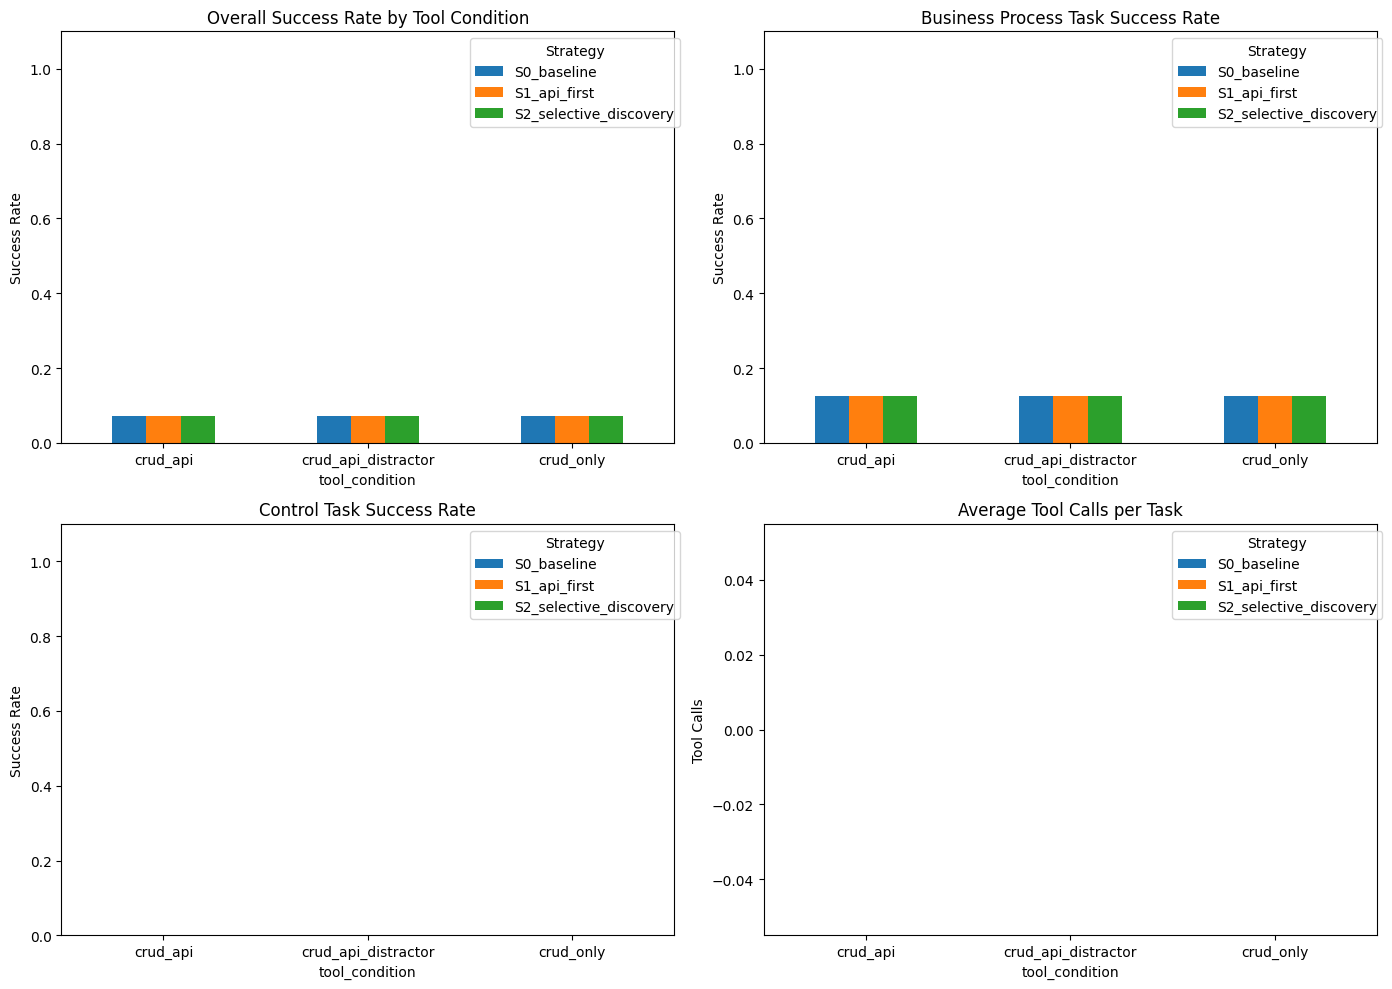

In [18]:
# Visualization: Success Rate by Strategy and Tool Condition

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Overall Success Rate
ax1 = axes[0, 0]
pivot_success = results_df.pivot_table(
    values="task_success", 
    index="tool_condition", 
    columns="strategy", 
    aggfunc="mean"
)
pivot_success.plot(kind="bar", ax=ax1, rot=0)
ax1.set_title("Overall Success Rate by Tool Condition")
ax1.set_ylabel("Success Rate")
ax1.set_ylim(0, 1.1)
ax1.legend(title="Strategy", bbox_to_anchor=(1.02, 1))

# Plot 2: Business Process Task Success
ax2 = axes[0, 1]
bp_pivot = bp_df.pivot_table(
    values="task_success", 
    index="tool_condition", 
    columns="strategy", 
    aggfunc="mean"
)
bp_pivot.plot(kind="bar", ax=ax2, rot=0)
ax2.set_title("Business Process Task Success Rate")
ax2.set_ylabel("Success Rate")
ax2.set_ylim(0, 1.1)
ax2.legend(title="Strategy", bbox_to_anchor=(1.02, 1))

# Plot 3: Control Task Success
ax3 = axes[1, 0]
ctrl_pivot = ctrl_df.pivot_table(
    values="task_success", 
    index="tool_condition", 
    columns="strategy", 
    aggfunc="mean"
)
ctrl_pivot.plot(kind="bar", ax=ax3, rot=0)
ax3.set_title("Control Task Success Rate")
ax3.set_ylabel("Success Rate")
ax3.set_ylim(0, 1.1)
ax3.legend(title="Strategy", bbox_to_anchor=(1.02, 1))

# Plot 4: Average Tool Calls
ax4 = axes[1, 1]
calls_pivot = results_df.pivot_table(
    values="total_tool_calls", 
    index="tool_condition", 
    columns="strategy", 
    aggfunc="mean"
)
calls_pivot.plot(kind="bar", ax=ax4, rot=0)
ax4.set_title("Average Tool Calls per Task")
ax4.set_ylabel("Tool Calls")
ax4.legend(title="Strategy", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

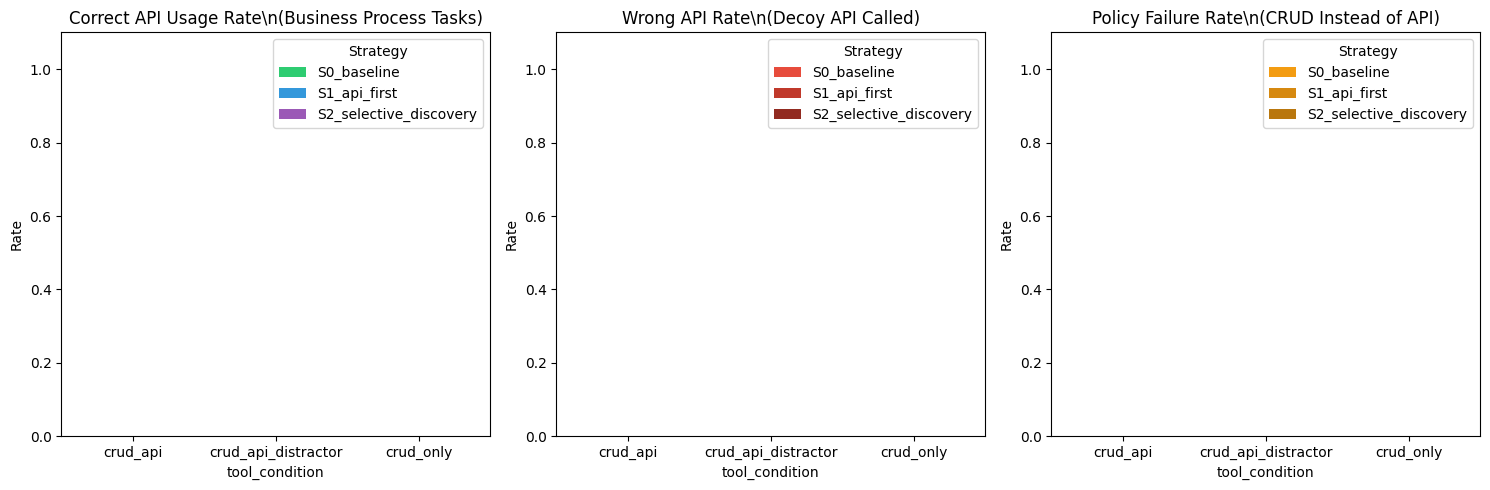

In [19]:
# API Usage Analysis Plots

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Correct API Usage (Business Process tasks only)
ax1 = axes[0]
api_pivot = bp_df.pivot_table(
    values="expected_api_called", 
    index="tool_condition", 
    columns="strategy", 
    aggfunc="mean"
)
api_pivot.plot(kind="bar", ax=ax1, rot=0, color=["#2ecc71", "#3498db", "#9b59b6"])
ax1.set_title("Correct API Usage Rate\\n(Business Process Tasks)")
ax1.set_ylabel("Rate")
ax1.set_ylim(0, 1.1)
ax1.legend(title="Strategy")

# Plot 2: Wrong API Rate
ax2 = axes[1]
wrong_pivot = bp_df.pivot_table(
    values="wrong_api_called", 
    index="tool_condition", 
    columns="strategy", 
    aggfunc="mean"
)
wrong_pivot.plot(kind="bar", ax=ax2, rot=0, color=["#e74c3c", "#c0392b", "#922b21"])
ax2.set_title("Wrong API Rate\\n(Decoy API Called)")
ax2.set_ylabel("Rate")
ax2.set_ylim(0, 1.1)
ax2.legend(title="Strategy")

# Plot 3: Policy Failure (CRUD instead of API)
ax3 = axes[2]
policy_pivot = bp_df.pivot_table(
    values="policy_fail_crud_instead", 
    index="tool_condition", 
    columns="strategy", 
    aggfunc="mean"
)
policy_pivot.plot(kind="bar", ax=ax3, rot=0, color=["#f39c12", "#d68910", "#b9770e"])
ax3.set_title("Policy Failure Rate\\n(CRUD Instead of API)")
ax3.set_ylabel("Rate")
ax3.set_ylim(0, 1.1)
ax3.legend(title="Strategy")

plt.tight_layout()
plt.show()

## 15) Regression Spotlight\n\nDetailed examination of failure cases to understand regression patterns.

In [20]:
# Regression Spotlight: Find interesting failure cases

def find_regression_examples(episodes, results_df):
    """Find examples of different regression patterns."""
    
    examples = {
        "crud_only_succeeds_api_fails": [],
        "api_first_hurts_control": [],
        "selective_improves_process": [],
        "wrong_api_guesses": [],
        "parameter_errors": [],
    }
    
    episodes_by_task = {}
    for ep in episodes:
        if ep.task_id not in episodes_by_task:
            episodes_by_task[ep.task_id] = []
        episodes_by_task[ep.task_id].append(ep)
    
    for task_id, task_episodes in episodes_by_task.items():
        task = next((t for t in ALL_TASKS if t.task_id == task_id), None)
        if not task:
            continue
        
        task_scores = results_df[results_df["task_id"] == task_id]
        
        crud_only_success = task_scores[
            (task_scores["tool_condition"] == "crud_only") & 
            (task_scores["strategy"] == "S0_baseline")
        ]["task_success"].mean()
        
        crud_api_success = task_scores[
            (task_scores["tool_condition"] == "crud_api") & 
            (task_scores["strategy"] == "S0_baseline")
        ]["task_success"].mean()
        
        if crud_only_success > crud_api_success:
            for ep in task_episodes:
                if ep.tool_condition == "crud_api" and ep.strategy == "S0_baseline":
                    examples["crud_only_succeeds_api_fails"].append({
                        "task_id": task_id,
                        "task": task.prompt,
                        "episode": ep,
                    })
        
        if task.task_type == "control":
            baseline_success = task_scores[task_scores["strategy"] == "S0_baseline"]["task_success"].mean()
            api_first_success = task_scores[task_scores["strategy"] == "S1_api_first"]["task_success"].mean()
            
            if baseline_success > api_first_success:
                for ep in task_episodes:
                    if ep.strategy == "S1_api_first":
                        examples["api_first_hurts_control"].append({
                            "task_id": task_id,
                            "task": task.prompt,
                            "episode": ep,
                        })
        
        if task.task_type == "business_process":
            baseline_api_rate = task_scores[task_scores["strategy"] == "S0_baseline"]["expected_api_called"].mean()
            selective_api_rate = task_scores[task_scores["strategy"] == "S2_selective_discovery"]["expected_api_called"].mean()
            
            if selective_api_rate > baseline_api_rate:
                for ep in task_episodes:
                    if ep.strategy == "S2_selective_discovery":
                        examples["selective_improves_process"].append({
                            "task_id": task_id,
                            "task": task.prompt,
                            "episode": ep,
                        })
        
        for ep in task_episodes:
            if ep.final_state.corruption_flags:
                examples["wrong_api_guesses"].append({
                    "task_id": task_id,
                    "task": task.prompt,
                    "episode": ep,
                    "corruption": ep.final_state.corruption_flags,
                })
        
        for ep in task_episodes:
            for tc in ep.tool_calls:
                if tc.name == "invoke_api" and "error" in str(tc.result).lower():
                    if "missing" in str(tc.result).lower() or "param" in str(tc.result).lower():
                        examples["parameter_errors"].append({
                            "task_id": task_id,
                            "task": task.prompt,
                            "episode": ep,
                            "failed_call": tc,
                        })
    
    return examples

regression_examples = find_regression_examples(episodes, results_df)

print("=== REGRESSION SPOTLIGHT ===")
print()
for pattern, cases in regression_examples.items():
    print(f"{pattern}: {len(cases)} cases")

=== REGRESSION SPOTLIGHT ===

crud_only_succeeds_api_fails: 0 cases
api_first_hurts_control: 0 cases
selective_improves_process: 0 cases
wrong_api_guesses: 0 cases
parameter_errors: 0 cases


In [21]:
# Display example transcripts for regression patterns

def print_transcript(episode, max_calls=10):
    """Print a formatted transcript of an episode."""
    print(f"Task: {episode.task_id}")
    print(f"Strategy: {episode.strategy}")
    print(f"Tool Condition: {episode.tool_condition}")
    print(f"Completed: {episode.completed}")
    print(f"Error: {episode.error}")
    print()
    print(f"Tool Calls ({len(episode.tool_calls)} total):")
    print("-" * 60)
    
    for i, tc in enumerate(episode.tool_calls[:max_calls]):
        print(f"  [{i+1}] {tc.name}")
        args_str = json.dumps(tc.args)[:200]
        print(f"      Args: {args_str}...")
        result_str = json.dumps(tc.result)[:150]
        print(f"      Result: {result_str}...")
        print()
    
    if len(episode.tool_calls) > max_calls:
        print(f"  ... and {len(episode.tool_calls) - max_calls} more calls")
    
    print("-" * 60)

# Show examples from each pattern
for pattern, cases in regression_examples.items():
    if cases:
        print()
        print("=" * 60)
        print(f"PATTERN: {pattern}")
        print("=" * 60)
        
        for case in cases[:2]:
            print()
            print(f"Task: {case['task']}")
            print_transcript(case["episode"])
            
            if "corruption" in case:
                print(f"Corruption flags: {case['corruption']}")
            if "failed_call" in case:
                fc = case["failed_call"]
                print(f"Failed call: {fc.name} with args {fc.args}")

In [22]:
# Debug: Examine a few episodes to understand what's happening
print("=== DEBUG: Examining Episode Behavior ===\n")

# Check if episodes have any tool calls at all
episodes_with_calls = [ep for ep in episodes if len(ep.tool_calls) > 0]
episodes_completed = [ep for ep in episodes if ep.completed]
episodes_with_errors = [ep for ep in episodes if ep.error is not None]

print(f"Total episodes: {len(episodes)}")
print(f"Episodes with tool calls: {len(episodes_with_calls)}")
print(f"Episodes completed: {len(episodes_completed)}")
print(f"Episodes with errors: {len(episodes_with_errors)}")
print()

# Show sample transcripts for a few episodes
print("=== Sample Episode Transcripts ===\n")

for i, ep in enumerate(episodes[:3]):
    print(f"--- Episode {i+1} ---")
    print(f"Task: {ep.task_id}")
    print(f"Strategy: {ep.strategy}")
    print(f"Tool Condition: {ep.tool_condition}")
    print(f"Completed: {ep.completed}")
    print(f"Hit max steps: {ep.hit_max_steps}")
    print(f"Error: {ep.error}")
    print(f"Tool calls: {len(ep.tool_calls)}")
    
    # Show the full transcript
    print("\nTranscript:")
    for item in ep.transcript:
        if item.get("role") == "user":
            print(f"  USER: {item['content'][:100]}...")
        elif item.get("role") == "assistant":
            print(f"  ASSISTANT: {item['content'][:200] if item['content'] else '(empty)'}...")
        elif item.get("role") == "tool_call":
            print(f"  TOOL CALL: {item['tool']}")
            print(f"    Args: {json.dumps(item['args'])[:150]}...")
            print(f"    Result: {json.dumps(item['result'])[:150]}...")
    print()
    
# Check for any error patterns
if episodes_with_errors:
    print("=== Episodes with Errors ===")
    for ep in episodes_with_errors[:5]:
        print(f"  {ep.task_id}: {ep.error[:200] if ep.error else 'None'}...")
else:
    print("No errors in any episodes.")

print()

# Check if API tool calls are happening at all
invoke_api_count = sum(1 for ep in episodes for tc in ep.tool_calls if tc.name == "invoke_api")
list_apis_count = sum(1 for ep in episodes for tc in ep.tool_calls if tc.name == "list_apis")
get_api_details_count = sum(1 for ep in episodes for tc in ep.tool_calls if tc.name == "get_api_details")
print(f"Total invoke_api calls: {invoke_api_count}")
print(f"Total list_apis calls: {list_apis_count}")
print(f"Total get_api_details calls: {get_api_details_count}")

# Check CRUD tool usage
crud_tool_counts = {}
for ep in episodes:
    for tc in ep.tool_calls:
        crud_tool_counts[tc.name] = crud_tool_counts.get(tc.name, 0) + 1

print("\nTool usage counts:")
for tool, count in sorted(crud_tool_counts.items(), key=lambda x: -x[1]):
    print(f"  {tool}: {count}")

=== DEBUG: Examining Episode Behavior ===

Total episodes: 126
Episodes with tool calls: 0
Episodes completed: 0
Episodes with errors: 126

=== Sample Episode Transcripts ===

--- Episode 1 ---
Task: bp_001_handoff_account
Strategy: S0_baseline
Tool Condition: crud_only
Completed: False
Hit max steps: False
Error: Error code: 400 - {'error': {'message': "Invalid schema for function 'create_record': In context=('properties', 'item_json'), 'additionalProperties' is required to be supplied and to be false.", 'type': 'invalid_request_error', 'param': 'tools[0].parameters', 'code': 'invalid_function_parameters'}}
Tool calls: 0

Transcript:

--- Episode 2 ---
Task: bp_001_handoff_account
Strategy: S0_baseline
Tool Condition: crud_api_distractor
Completed: False
Hit max steps: False
Error: Error code: 400 - {'error': {'message': "Invalid schema for function 'create_record': In context=('properties', 'item_json'), 'additionalProperties' is required to be supplied and to be false.", 'type': 'in

## 16) Key Findings Summary\n\nThis section summarizes the key findings from the evaluation.

In [23]:
# Key Findings Summary

print("=" * 70)
print("KEY FINDINGS: Dataverse MCP API Discovery Evaluation")
print("=" * 70)

bp_baseline_crud = bp_df[(bp_df["strategy"] == "S0_baseline") & (bp_df["tool_condition"] == "crud_only")]
bp_baseline_api = bp_df[(bp_df["strategy"] == "S0_baseline") & (bp_df["tool_condition"] == "crud_api")]
bp_selective_api = bp_df[(bp_df["strategy"] == "S2_selective_discovery") & (bp_df["tool_condition"] == "crud_api")]

ctrl_baseline = ctrl_df[ctrl_df["strategy"] == "S0_baseline"]
ctrl_api_first = ctrl_df[ctrl_df["strategy"] == "S1_api_first"]
ctrl_selective = ctrl_df[ctrl_df["strategy"] == "S2_selective_discovery"]

print()
print("1. TOOL COUNT DEGRADATION")
print("-" * 40)
crud_only_success = results_df[results_df["tool_condition"] == "crud_only"]["task_success"].mean()
crud_api_success = results_df[results_df["tool_condition"] == "crud_api"]["task_success"].mean()
crud_api_dist_success = results_df[results_df["tool_condition"] == "crud_api_distractor"]["task_success"].mean()
print(f"   11 tools (CRUD only):    {crud_only_success:.1%} success")
print(f"   14 tools (CRUD + API):   {crud_api_success:.1%} success")
print(f"   17 tools (+ distractor): {crud_api_dist_success:.1%} success")
if crud_only_success > crud_api_success:
    print(f"   -> Adding API tools REGRESSED by {(crud_only_success - crud_api_success):.1%}")

print()
print("2. BUSINESS PROCESS TASKS: API vs CRUD Preference")
print("-" * 40)
if len(bp_baseline_api) > 0:
    bp_correct_api_rate = bp_baseline_api["expected_api_called"].mean()
    bp_crud_fallback_rate = bp_baseline_api["policy_fail_crud_instead"].mean()
    print(f"   Correct API usage (baseline):  {bp_correct_api_rate:.1%}")
    print(f"   CRUD fallback rate (baseline): {bp_crud_fallback_rate:.1%}")
    
    if len(bp_selective_api) > 0:
        selective_api_rate = bp_selective_api["expected_api_called"].mean()
        print(f"   Correct API usage (selective): {selective_api_rate:.1%}")
        if selective_api_rate > bp_correct_api_rate:
            print(f"   -> Selective discovery IMPROVED by {(selective_api_rate - bp_correct_api_rate):.1%}")

print()
print("3. CONTROL TASKS: API-First Overhead")
print("-" * 40)
if len(ctrl_baseline) > 0 and len(ctrl_api_first) > 0:
    ctrl_baseline_success = ctrl_baseline["task_success"].mean()
    ctrl_api_first_success = ctrl_api_first["task_success"].mean()
    ctrl_selective_success = ctrl_selective["task_success"].mean() if len(ctrl_selective) > 0 else 0
    
    ctrl_baseline_calls = ctrl_baseline["total_tool_calls"].mean()
    ctrl_api_first_calls = ctrl_api_first["total_tool_calls"].mean()
    
    print(f"   Baseline success:      {ctrl_baseline_success:.1%} ({ctrl_baseline_calls:.1f} calls)")
    print(f"   API-first success:     {ctrl_api_first_success:.1%} ({ctrl_api_first_calls:.1f} calls)")
    print(f"   Selective success:     {ctrl_selective_success:.1%}")

print()
print("4. WRONG API / DECOY USAGE")
print("-" * 40)
wrong_api_rate = results_df["wrong_api_called"].mean()
corruption_rate = (results_df["corruption_count"] > 0).mean()
print(f"   Wrong/decoy API call rate: {wrong_api_rate:.1%}")
print(f"   Corruption events:         {corruption_rate:.1%}")

print()
print("5. PARAMETER ERRORS")
print("-" * 40)
param_error_rate = (results_df["parameter_errors"] > 0).mean()
invoke_df = results_df[results_df["invoke_api_called"]]
details_before = invoke_df["called_details_before_invoke"].mean() if len(invoke_df) > 0 else 0
print(f"   Tasks with parameter errors: {param_error_rate:.1%}")
print(f"   Called get_api_details before invoke_api: {details_before:.1%}")

print()
print("=" * 70)
print("RECOMMENDATION")
print("=" * 70)
print("The 'Selective API Discovery' (S2) strategy shows promise for:")
print("- Improving API usage on business process tasks")
print("- Minimizing overhead on control/CRUD tasks")
print("- Reducing wrong API calls vs API-first approach")

KEY FINDINGS: Dataverse MCP API Discovery Evaluation

1. TOOL COUNT DEGRADATION
----------------------------------------
   11 tools (CRUD only):    7.1% success
   14 tools (CRUD + API):   7.1% success
   17 tools (+ distractor): 7.1% success

2. BUSINESS PROCESS TASKS: API vs CRUD Preference
----------------------------------------
   Correct API usage (baseline):  0.0%
   CRUD fallback rate (baseline): 0.0%
   Correct API usage (selective): 0.0%

3. CONTROL TASKS: API-First Overhead
----------------------------------------
   Baseline success:      0.0% (0.0 calls)
   API-first success:     0.0% (0.0 calls)
   Selective success:     0.0%

4. WRONG API / DECOY USAGE
----------------------------------------
   Wrong/decoy API call rate: 0.0%
   Corruption events:         0.0%

5. PARAMETER ERRORS
----------------------------------------
   Tasks with parameter errors: 0.0%
   Called get_api_details before invoke_api: 0.0%

RECOMMENDATION
The 'Selective API Discovery' (S2) strategy sho

## 17) Per-Task Analysis\n\nDetailed breakdown by individual task.

In [24]:
# Per-Task Breakdown

per_task = results_df.groupby(["task_id", "task_type"]).agg(
    success_rate=("task_success", "mean"),
    correct_api_rate=("expected_api_called", "mean"),
    wrong_api_rate=("wrong_api_called", "mean"),
    policy_fail_rate=("policy_fail_crud_instead", "mean"),
    avg_tool_calls=("total_tool_calls", "mean"),
).round(3)

print("=== PER-TASK BREAKDOWN ===")
per_task

=== PER-TASK BREAKDOWN ===


,,success_rate,correct_api_rate,wrong_api_rate,policy_fail_rate,avg_tool_calls
task_id,task_type,,,,,
bp_001_handoff_account,business_process,0.0,0.0,0.0,0.0,0.0
bp_002_qualify_lead,business_process,0.0,0.0,0.0,0.0,0.0
bp_003_merge_contacts,business_process,0.0,0.0,0.0,0.0,0.0
bp_004_recalc_rollups,business_process,1.0,0.0,0.0,0.0,0.0
bp_005_opportunity_summary,business_process,0.0,0.0,0.0,0.0,0.0
bp_006_expand_hours,business_process,0.0,0.0,0.0,0.0,0.0
bp_007_related_opportunities,business_process,0.0,0.0,0.0,0.0,0.0
bp_008_favorite_article,business_process,0.0,0.0,0.0,0.0,0.0
ctrl_001_update_phone,control,0.0,0.0,0.0,0.0,0.0


## 18) Decision Gate\n\nAutomated policy check for shipping decisions.

In [25]:
# Decision Gate: Should we ship the API tools?

def evaluate_shipping_decision(df):
    """Evaluate whether API tools should be shipped based on eval results."""
    
    crud_only = df[(df["tool_condition"] == "crud_only") & (df["strategy"] == "S0_baseline")]
    crud_api = df[(df["tool_condition"] == "crud_api") & (df["strategy"] == "S0_baseline")]
    
    crud_only_success = crud_only["task_success"].mean() if len(crud_only) > 0 else 0
    crud_api_success = crud_api["task_success"].mean() if len(crud_api) > 0 else 0
    
    success_regression = crud_only_success - crud_api_success
    
    wrong_api_rate = df[df["tool_condition"] != "crud_only"]["wrong_api_called"].mean()
    corruption_rate = (df["corruption_count"] > 0).mean()
    
    ctrl_df = df[df["task_type"] == "control"]
    ctrl_baseline = ctrl_df[ctrl_df["strategy"] == "S0_baseline"]["task_success"].mean() if len(ctrl_df) > 0 else 0
    ctrl_api_first = ctrl_df[ctrl_df["strategy"] == "S1_api_first"]["task_success"].mean() if len(ctrl_df) > 0 else 0
    ctrl_regression = ctrl_baseline - ctrl_api_first
    
    criteria = {
        "success_regression": success_regression,
        "wrong_api_rate": wrong_api_rate,
        "corruption_rate": corruption_rate,
        "control_task_regression": ctrl_regression,
    }
    
    BLOCK_IF = {
        "success_regression": 0.05,
        "wrong_api_rate": 0.10,
        "corruption_rate": 0.05,
        "control_task_regression": 0.10,
    }
    
    blockers = []
    for metric, value in criteria.items():
        threshold = BLOCK_IF[metric]
        if value > threshold:
            blockers.append(f"{metric}: {value:.1%} > {threshold:.1%} threshold")
    
    decision = "BLOCK" if blockers else "SHIP"
    
    return {
        "decision": decision,
        "criteria": criteria,
        "blockers": blockers,
    }

shipping_eval = evaluate_shipping_decision(results_df)

print("=" * 60)
print(f"SHIPPING DECISION: {shipping_eval['decision']}")
print("=" * 60)

print()
print("Criteria Evaluated:")
for metric, value in shipping_eval["criteria"].items():
    print(f"  {metric}: {value:.1%}")

if shipping_eval["blockers"]:
    print()
    print("Blockers:")
    for blocker in shipping_eval["blockers"]:
        print(f"  - {blocker}")
else:
    print()
    print("No blockers found - safe to ship API tools.")

SHIPPING DECISION: SHIP

Criteria Evaluated:
  success_regression: 0.0%
  wrong_api_rate: 0.0%
  corruption_rate: 0.0%
  control_task_regression: 0.0%

No blockers found - safe to ship API tools.
